In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import chi2_contingency, f_oneway
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score

# Read in data

In [2]:
model_df = pd.read_csv('model_data.csv')

# Pre-process data for clustering analysis

## Exclude churn status and standardize data

In [4]:
# Exclude churn_status from clustering features
cluster_features = [col for col in model_df.columns if col != 'Churn']

print(f"Features for clustering: {len(cluster_features)}")
print(f"Feature names: {cluster_features}")

# Scale features (crucial for K-Means)
X = model_df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nData scaled: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features")

Features for clustering: 23
Feature names: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Contract_One year', 'Contract_Two year']

Data scaled: 7043 samples, 23 features


## Determine Optimal Number of Clusters with elbow method and silhouette score

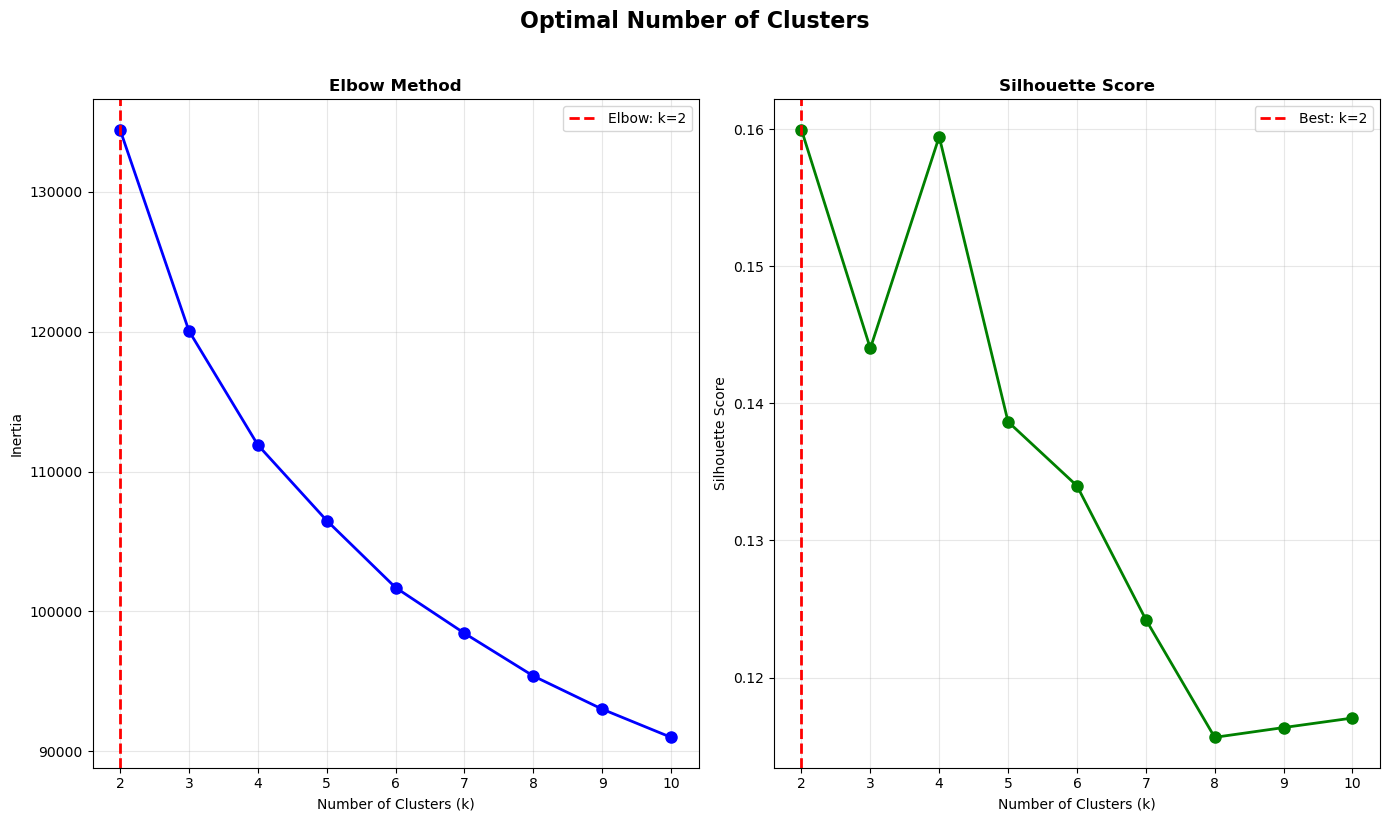

OPTIMAL NUMBER OF CLUSTERS - RESULTS
    K      Inertia  Silhouette
0   2  134445.0620      0.1600
1   3  120058.8459      0.1440
2   4  111905.7243      0.1595
3   5  106501.2724      0.1387
4   6  101706.8375      0.1340
5   7   98438.9342      0.1242
6   8   95384.7520      0.1156
7   9   93013.0637      0.1164
8  10   90998.2241      0.1170
RECOMMENDATIONS
Elbow Method suggests: k = 2
Silhouette Score suggests: k = 2 (score: 0.160)


In [8]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Find Optimal K
def find_elbow(inertias):
    """Find elbow point using curvature"""
    diffs = np.diff(inertias)
    diffs2 = np.diff(diffs)
    elbow = np.argmax(diffs2) + 2
    return elbow

elbow_k = find_elbow(inertias)
silhouette_k = np.argmax(silhouette_scores) + 2

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Elbow Method
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(elbow_k, color='red', linestyle='--', linewidth=2, label=f'Elbow: k={elbow_k}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(silhouette_k, color='red', linestyle='--', linewidth=2, label=f'Best: k={silhouette_k}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Optimal Number of Clusters', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_optimal_k.png', dpi=450, bbox_inches='tight')
plt.show()

# Results Summary
results_df = pd.DataFrame({
    'K': k_range,
    'Inertia': inertias,
    'Silhouette': silhouette_scores
})

print("OPTIMAL NUMBER OF CLUSTERS - RESULTS")
print(results_df.round(4))

print("RECOMMENDATIONS")
print(f"Elbow Method suggests: k = {elbow_k}")
# Fixed index: silhouette_k - 2 because k=2 is at index 0
print(f"Silhouette Score suggests: k = {silhouette_k} (score: {silhouette_scores[silhouette_k - 2]:.3f})")

# Save results
results_df.to_excel('cluster_optimal_k_results.xlsx', index=False)

# Perform Clustering with optimal K

In [9]:
# Run K-Means with Chosen K
final_k = elbow_k

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to data
model_df_clustered = model_df.copy()
model_df_clustered['Cluster'] = clusters

# Get cluster centers in original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=cluster_features)

print("CLUSTERING COMPLETE")
print(f"Number of clusters: {final_k}")
print(f"\nCluster distribution:")
cluster_counts = model_df_clustered['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = (count / len(model_df_clustered)) * 100
    print(f"  Cluster {cluster}: {count} customers ({pct:.1f}%)")

CLUSTERING COMPLETE
Number of clusters: 2

Cluster distribution:
  Cluster 0: 3778 customers (53.6%)
  Cluster 1: 3265 customers (46.4%)


# Review Cluster Characteristics

In [12]:
# Cluster Profiles - All Features

# Calculate mean values by cluster
cluster_profiles = model_df_clustered.groupby('Cluster')[cluster_features].mean().round(3)

print("CLUSTER PROFILES - MEAN VALUES")
print(cluster_profiles)

# Also show median for robustness
cluster_profiles_median = model_df_clustered.groupby('Cluster')[cluster_features].median().round(3)

print("CLUSTER PROFILES - MEDIAN VALUES")
print(cluster_profiles_median)

cluster_profiles.to_excel('cluster_profiles_mean.xlsx')
cluster_profiles_median.to_excel('cluster_profiles_median.xlsx')

CLUSTER PROFILES - MEAN VALUES
         SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
Cluster                                                             
0                0.104    0.369       0.296  20.775         0.878   
1                0.229    0.615       0.304  45.790         0.932   

         MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  \
Cluster                                                                  
0                0.218           0.141         0.134             0.101   
1                0.658           0.455         0.588             0.625   

         TechSupport  ...  MonthlyCharges  TotalCharges  gender_Male  \
Cluster               ...                                              
0              0.118  ...          43.926       735.179        0.504   
1              0.489  ...          88.871      4066.971        0.505   

         InternetService_Fiber optic  InternetService_No  \
Cluster                                       

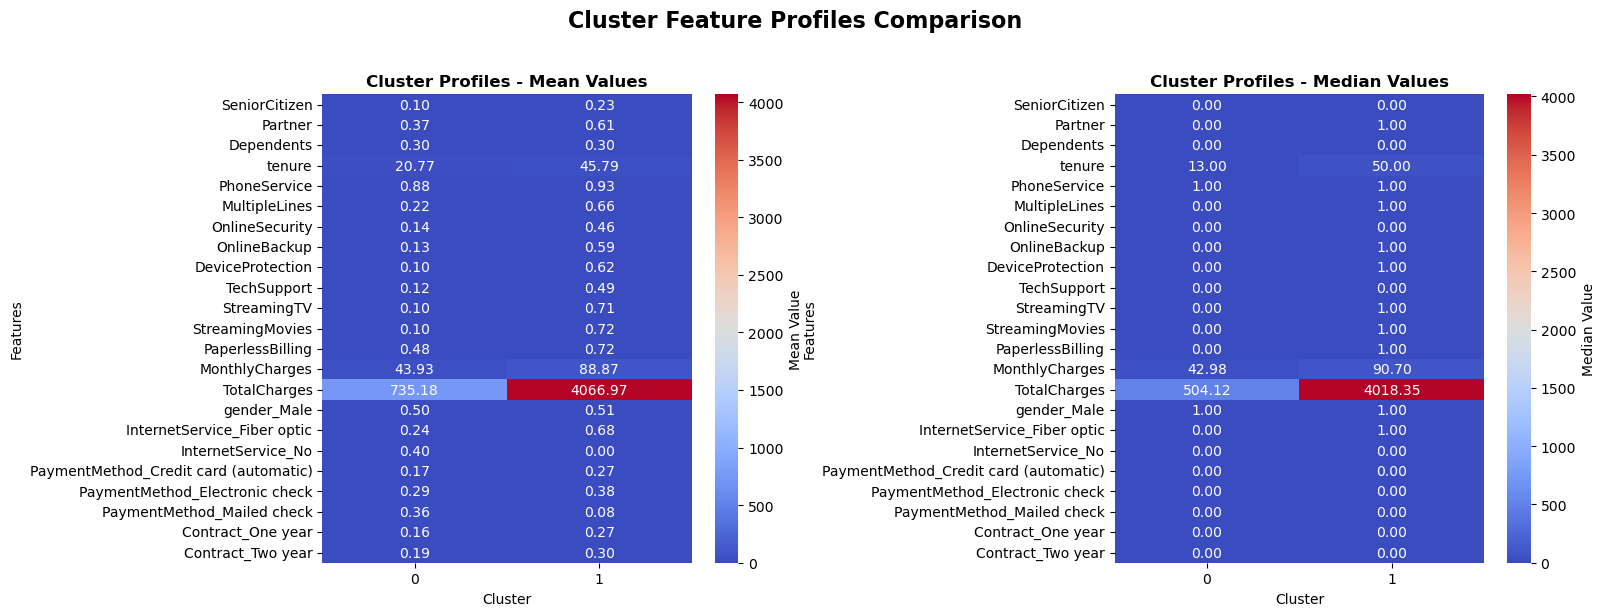

In [13]:
# Visualize cluster profiles with heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for Mean values
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={'label': 'Mean Value'}, ax=axes[0])
axes[0].set_title('Cluster Profiles - Mean Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Features')

# Heatmap for Median values
sns.heatmap(cluster_profiles_median.T, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={'label': 'Median Value'}, ax=axes[1])
axes[1].set_title('Cluster Profiles - Median Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Features')

plt.suptitle('Cluster Feature Profiles Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_profiles_heatmap.png', dpi=450, bbox_inches='tight')
plt.show()


# Churn Analysis by cluster

In [14]:
# Churn Rate by Cluster

churn_by_cluster = model_df_clustered.groupby('Cluster')['Churn'].agg(['mean', 'count'])
churn_by_cluster['Churn_Rate'] = churn_by_cluster['mean'] * 100
churn_by_cluster['%_of_Total'] = (churn_by_cluster['count'] / len(model_df_clustered)) * 100
churn_by_cluster = churn_by_cluster.sort_values('Churn_Rate', ascending=False)

print("CHURN RATE BY CLUSTER")
print(churn_by_cluster.round(2))

# ANOVA Test

# Group churn by cluster
groups = [model_df_clustered[model_df_clustered['Cluster'] == i]['Churn'] for i in range(final_k)]
f_stat, p_val = f_oneway(*groups)

print("STATISTICAL SIGNIFICANCE")
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_val:.4f}")
print(f"Significant at 95%: {'Yes' if p_val < 0.05 else 'No'}")
print(f"Significant at 99%: {'Yes' if p_val < 0.01 else 'No'}")

CHURN RATE BY CLUSTER
         mean  count  Churn_Rate  %_of_Total
Cluster                                     
0        0.28   3778       27.50       53.64
1        0.25   3265       25.42       46.36
STATISTICAL SIGNIFICANCE
ANOVA F-statistic: 3.8886
ANOVA p-value: 0.0487
Significant at 95%: Yes
Significant at 99%: No


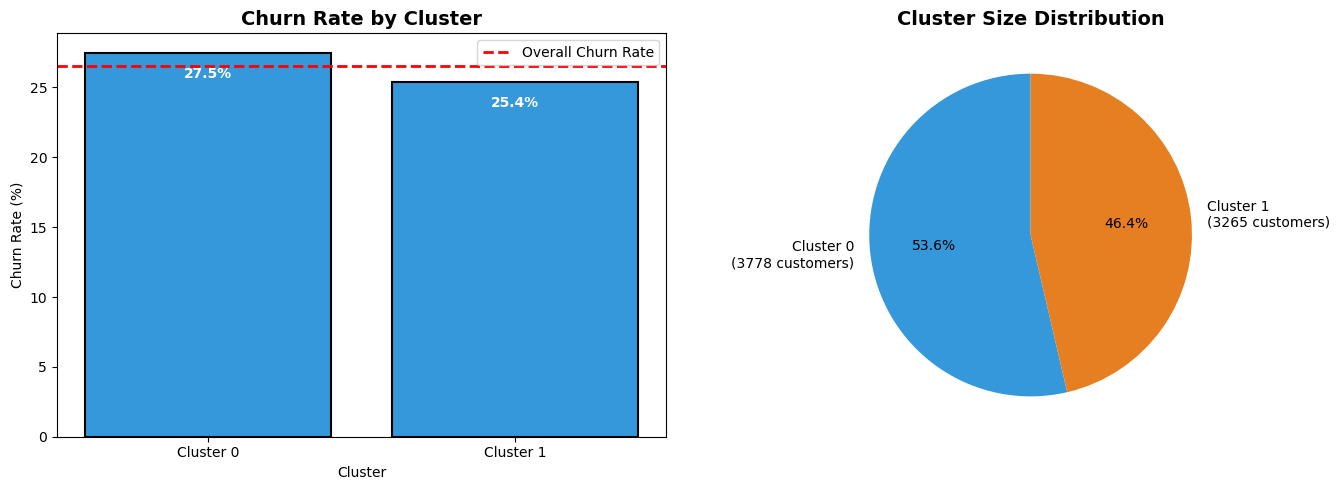

In [21]:
# Visualize Churn by Cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate bar chart
ax1 = axes[0]
colors = ['#A23B72' if rate > 30 else '#3498DB' for rate in churn_by_cluster['Churn_Rate']]
bars = ax1.bar(churn_by_cluster.index, churn_by_cluster['Churn_Rate'], color=colors, edgecolor='black', linewidth=1.5)
ax1.axhline(model_df['Churn'].mean() * 100, color='red', linestyle='--', linewidth=2, label='Overall Churn Rate')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate by Cluster', fontsize=14, fontweight='bold')
ax1.legend()
ax1.set_xticks(churn_by_cluster.index)  # Ensure only cluster numbers show
ax1.set_xticklabels([f'Cluster {i}' for i in churn_by_cluster.index])  # Label as discrete categories

# Add value labels
for bar, rate in zip(bars, churn_by_cluster['Churn_Rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1, 
            f'{rate:.1f}%', ha='center', va='top', fontweight='bold', color='white')

# Cluster size pie chart
ax2 = axes[1]
colors_pie = ['#3498DB', '#E67E22']
ax2.pie(churn_by_cluster['count'], 
        labels=[f'Cluster {i}\n({count} customers)' for i, count in churn_by_cluster['count'].items()], 
        autopct='%1.1f%%', startangle=90, colors=colors_pie[:len(churn_by_cluster)])
ax2.set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_by_cluster.png', dpi=450, bbox_inches='tight')
plt.show()

# Key Differentiating Features

In [22]:
# Identify Key Differentiators

# Calculate variance across clusters for each feature
feature_variance = cluster_profiles.var().sort_values(ascending=False)

print("KEY DIFFERENTIATING FEATURES")
print("Features with highest variance across clusters:")
print(feature_variance.head(10))

KEY DIFFERENTIATING FEATURES
Features with highest variance across clusters:
TotalCharges                   5.550419e+06
MonthlyCharges                 1.010027e+03
tenure                         3.128751e+02
StreamingMovies                1.903445e-01
StreamingTV                    1.854405e-01
DeviceProtection               1.372880e-01
OnlineBackup                   1.030580e-01
InternetService_Fiber optic    9.680000e-02
MultipleLines                  9.680000e-02
InternetService_No             8.160800e-02
dtype: float64


/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_5444/2211170161.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_df_clustered, x='Cluster', y=feature, ax=axes[i], palette=orange_blue_palette)
/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_5444/2211170161.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_df_clustered, x='Cluster', y=feature, ax=axes[i], palette=orange_blue_palette)
/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_5444/2211170161.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect

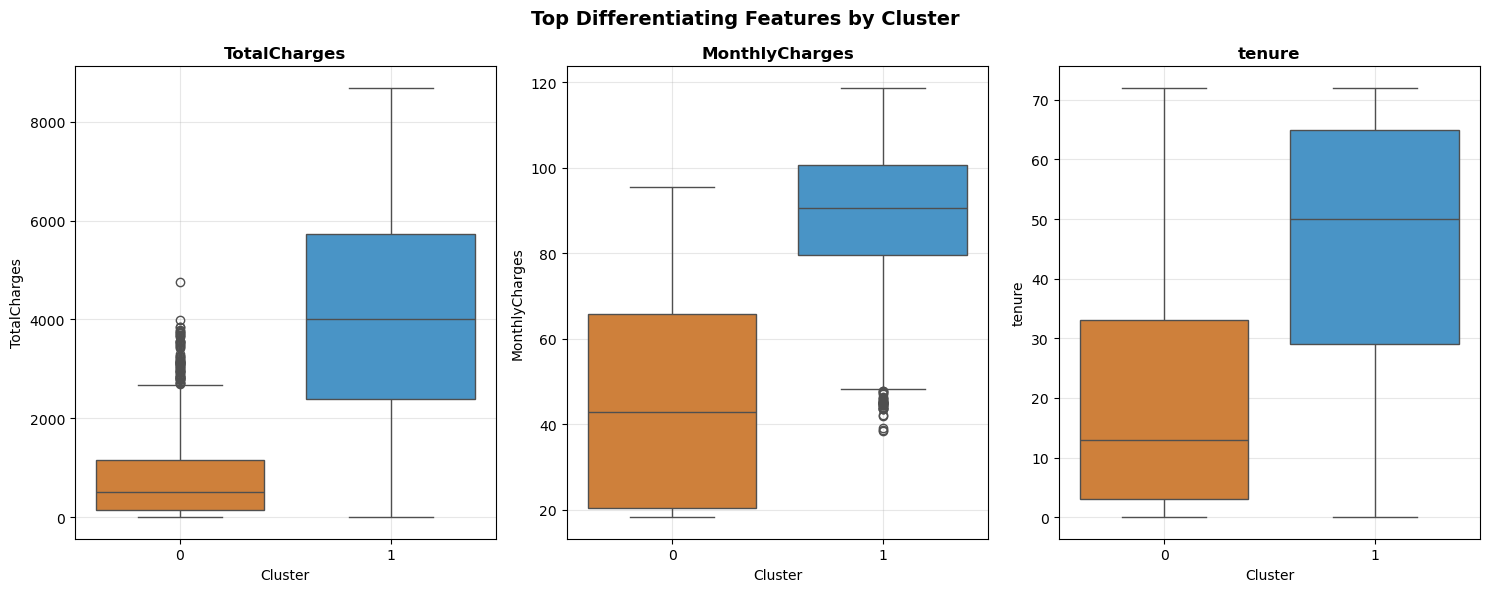

In [34]:
# Boxplots for Top Differentiators
top_features = feature_variance.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes = axes.flatten()

# Define custom orange and blue palette
orange_blue_palette = ['#E67E22', '#3498DB']

for i, feature in enumerate(top_features):
    if i < len(axes):
        sns.boxplot(data=model_df_clustered, x='Cluster', y=feature, ax=axes[i], palette=orange_blue_palette)
        axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Cluster')
        axes[i].grid(True, alpha=0.3)

# Remove empty subplot if any
if len(top_features) < len(axes):
    for i in range(len(top_features), len(axes)):
        fig.delaxes(axes[i])

plt.suptitle('Top Differentiating Features by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_features_by_cluster.png', dpi=450, bbox_inches='tight')
plt.show()